# HOMEWORK 4

For this homework you are going to implement a lane line detector. Lane line detection is crucial for ADAS (Advanced Driver Assistance Systems) systems and, in particular, for LKA (Lane Keep Assist). You will use a [picture](https://en.wikipedia.org/wiki/Lane_departure_warning_system) from a front facing camera (mounted on the car) and will implement the following steps:
* Convert image to gray scale
* Compute edge map
* Apply Hough transform to obtain line parametrizations

In [654]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load and show the camera frame.

Image shape: (600, 800, 3), diagonal length: 1000.00


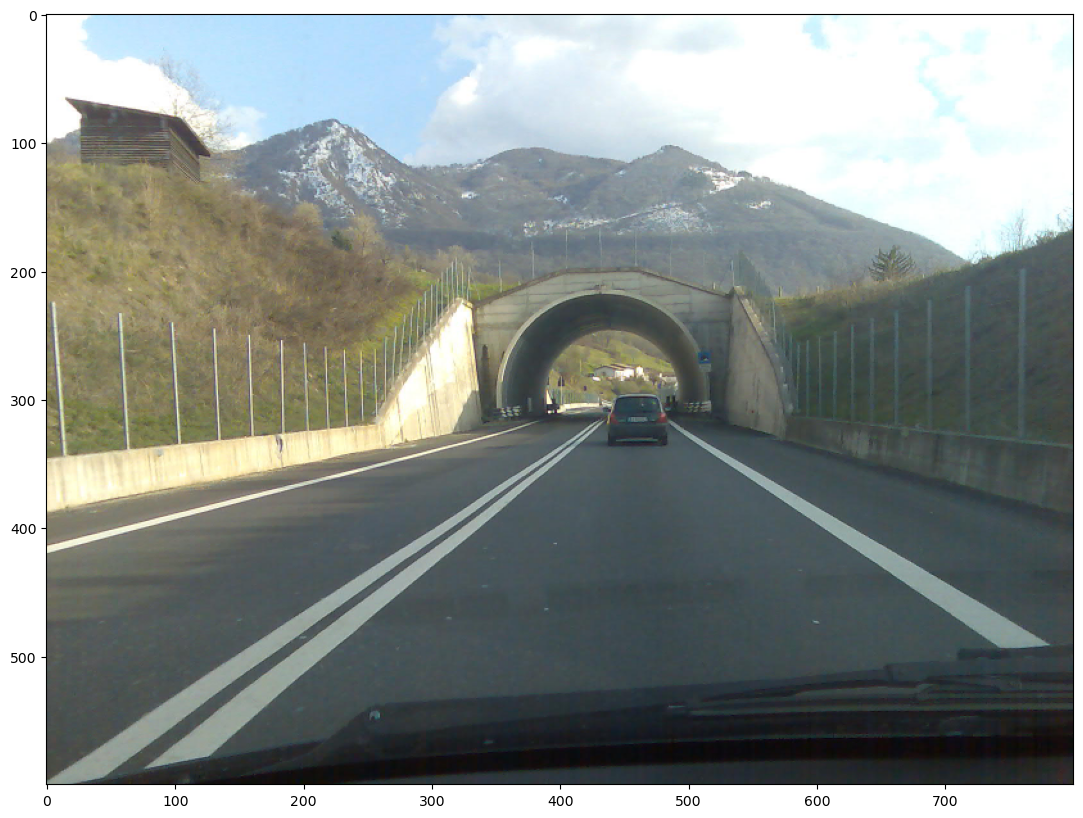

In [655]:
img = cv2.imread('./dashcam.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
scale = 0.5
img = cv2.resize(img, None, fx=scale, fy=scale)
line_len = math.sqrt(math.pow(img.shape[0], 2) + math.pow(img.shape[1], 2))
print(f'Image shape: {img.shape}, diagonal length: {line_len:.2f}')
plt.imshow(img)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

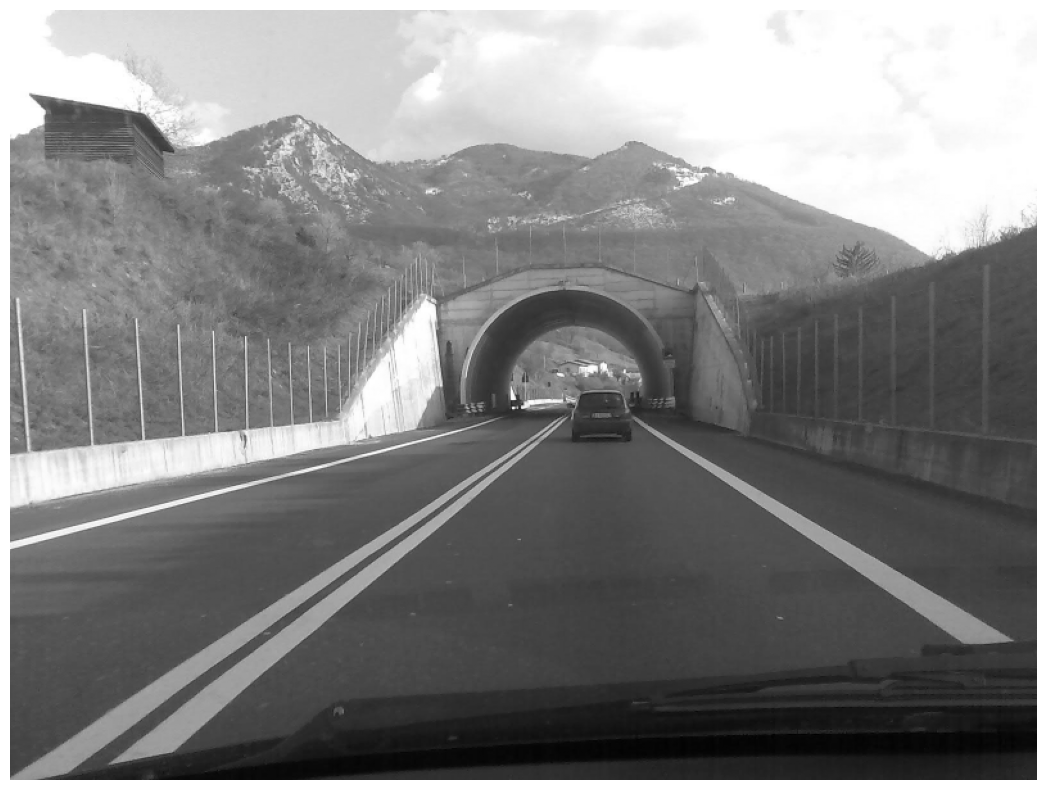

In [656]:
# Convert image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap='gray')
plt.axis('off')

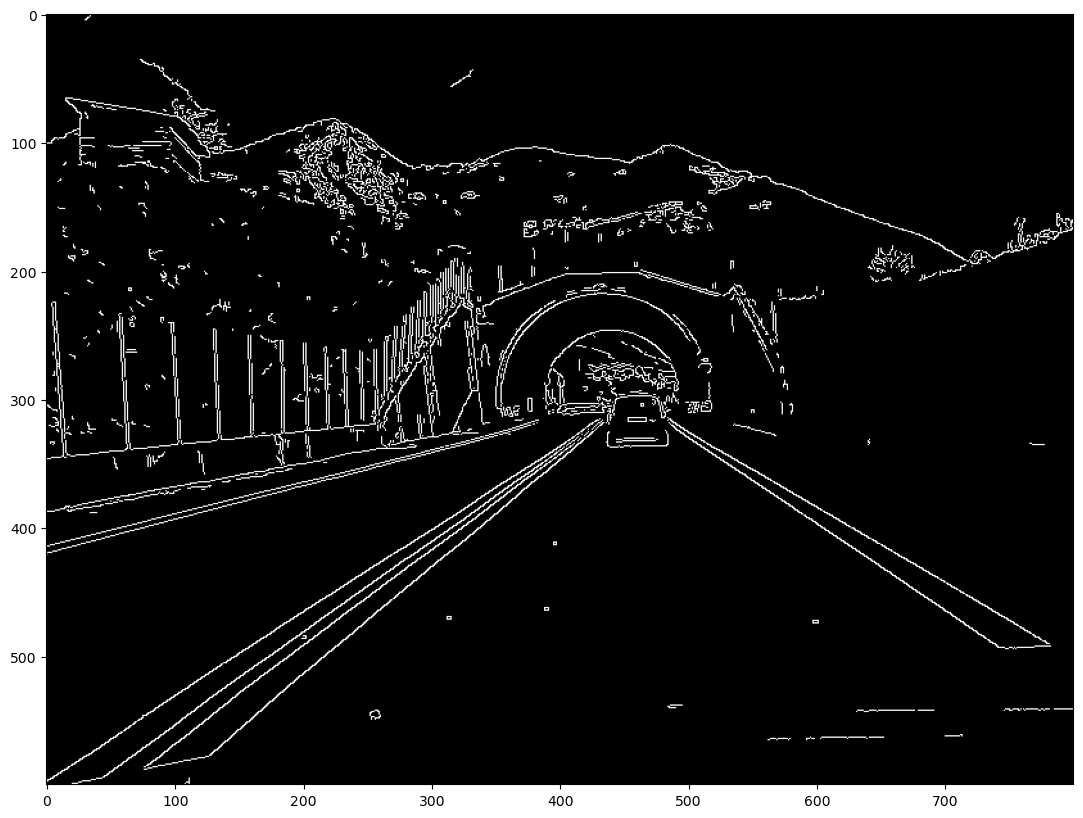

In [657]:
# Obtain edge map
# Hint: you can use Canny edge detector with th_low = 100, th_high = 150
edges = cv2.Canny(gray, 100, 150)

plt.imshow(edges, cmap='gray')

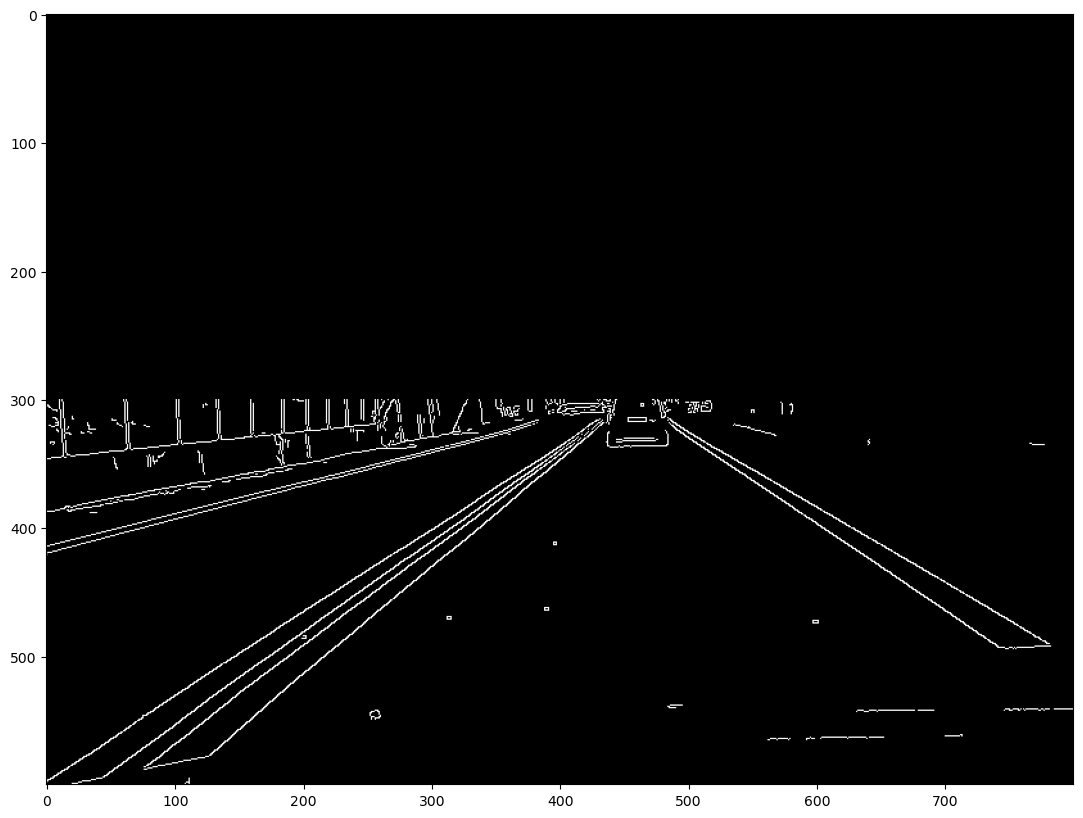

In [658]:

# We are only interseted in the road so we will remove everything above the horizon
edges[0:edges.shape[0] // 2] = 0
plt.imshow(edges, cmap='gray')

(<Axes: title={'center': 'Edge map'}>,
 Text(0.5, 1.0, 'Edge map'))

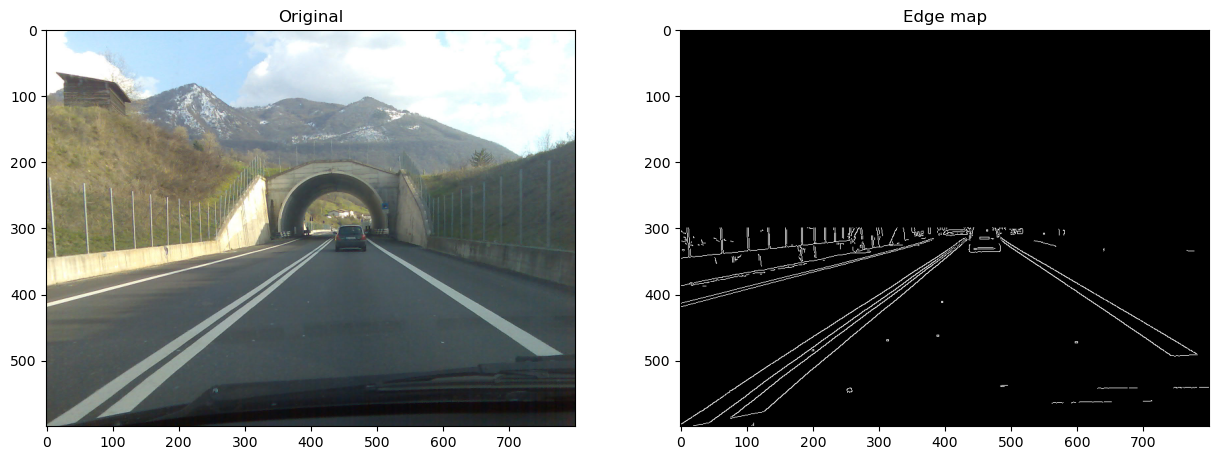

In [659]:
# Let's plot the images
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title('Edge map')

In [660]:
# Apply Hough transform to parametrize the lines
# Hint 1: Offset resolution of 2 pixels and slope resolution of 2 degrees work well in this case
# Hint 2: A suitable value for the accumulator threshold is 190
threshold = int(line_len / 6)
lines = cv2.HoughLines(edges, 2, np.pi / 90, threshold)
assert lines is not None, "No lines found"
print(f'Number of lines: {lines.shape[0]} using threshold {threshold}')
# Let's get rid of the unnecessary dimension
lines = lines[:, 0, :]
lines

Number of lines: 19 using threshold 166


array([[521.        ,   0.87266463],
       [401.        ,   1.3264502 ],
       [505.        ,   0.94247776],
       [509.        ,   0.9075712 ],
       [ -7.        ,   2.1642082 ],
       [343.        ,   1.4660766 ],
       [ 31.        ,   2.0943952 ],
       [495.        ,   0.9773844 ],
       [513.        ,   0.94247776],
       [499.        ,   1.012291  ],
       [379.        ,   1.3962634 ],
       [383.        ,   1.3613569 ],
       [511.        ,   0.9773844 ],
       [505.        ,   1.012291  ],
       [513.        ,   0.83775806],
       [409.        ,   1.2915436 ],
       [515.        ,   0.9773844 ],
       [517.        ,   0.83775806],
       [319.        ,   1.5358897 ]], dtype=float32)

(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

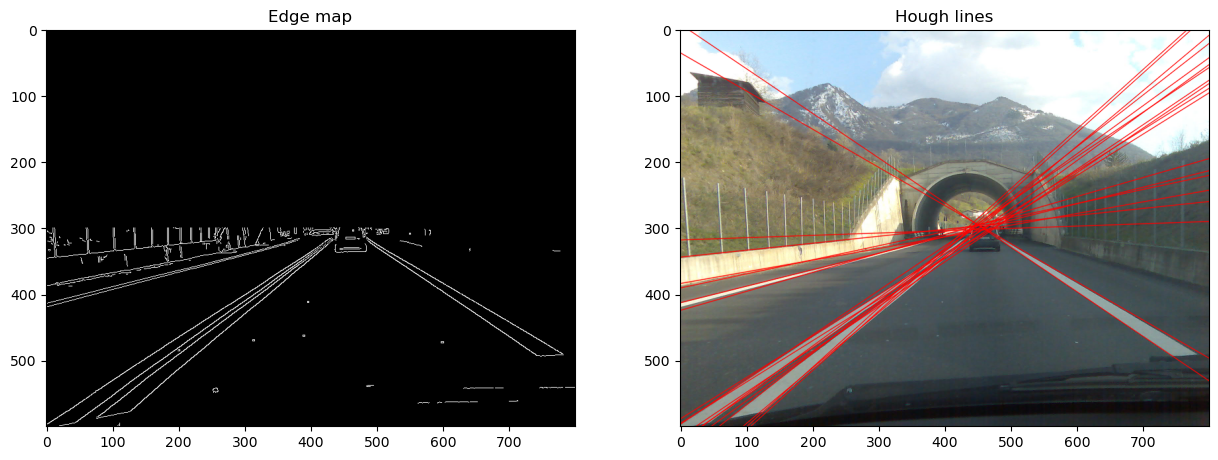

In [661]:
# Plot the resulting Hough lines
result = np.copy(img)

for line in lines:
    rho = line[0]
    theta = line[1]

    a = math.cos(theta)
    b = math.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + line_len*(-b)), int(y0 + line_len*(a)))
    pt2 = (int(x0 - line_len*(-b)), int(y0 - line_len*(a)))

    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

The edge map looks good but the Hough lines are too noisy. Let's clean the Hough lines first by removing all lines that we know cannot represent a lane line. In other words, all lines that are approximately horizontal shall be removed. Remember that horizontal lines correspond to theta = 90 degrees.

In [662]:
# Filter out all lines that are approximately horizontal (+/- 20 degrees).
filtered_lines = []

acceptable_angle = math.radians(20)
for line in lines:
    # Extract theta for current line (remember Hough works with radians)
    theta = math.pi / 2 - line[1]
    # Keep line if theta is not horizontal
    if theta > acceptable_angle or theta < -acceptable_angle:
        filtered_lines.append(line)

print(f'Number of lines after filtering: {len(filtered_lines)}')
filtered_lines

Number of lines after filtering: 13


[array([521.        ,   0.87266463], dtype=float32),
 array([505.        ,   0.94247776], dtype=float32),
 array([509.       ,   0.9075712], dtype=float32),
 array([-7.       ,  2.1642082], dtype=float32),
 array([31.       ,  2.0943952], dtype=float32),
 array([495.       ,   0.9773844], dtype=float32),
 array([513.        ,   0.94247776], dtype=float32),
 array([499.      ,   1.012291], dtype=float32),
 array([511.       ,   0.9773844], dtype=float32),
 array([505.      ,   1.012291], dtype=float32),
 array([513.        ,   0.83775806], dtype=float32),
 array([515.       ,   0.9773844], dtype=float32),
 array([517.        ,   0.83775806], dtype=float32)]

(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

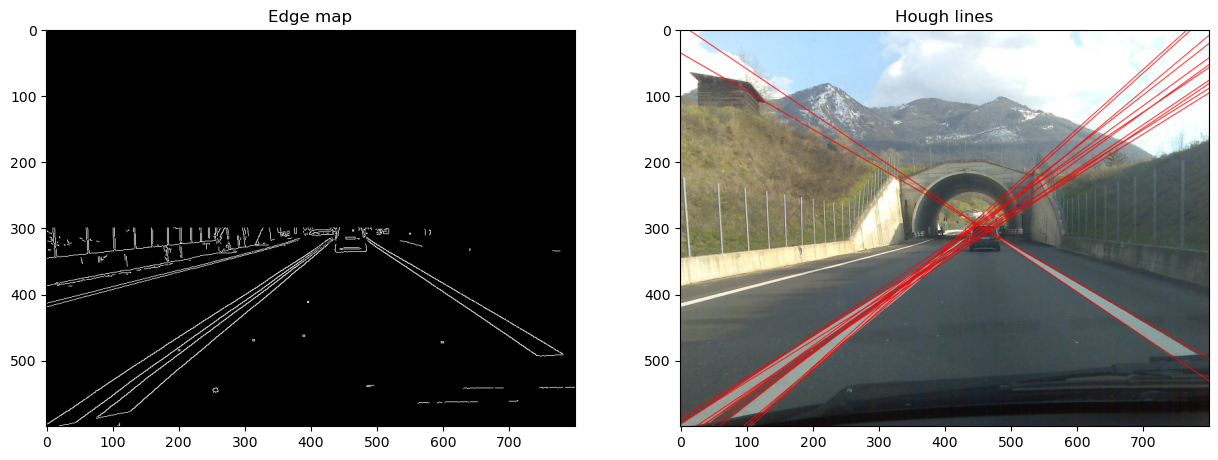

In [663]:
# Let's plot the resulting filtered lines
result = np.copy(img)

for line in filtered_lines:
    rho =   line[0]
    theta = line[1]
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + line_len*(-b)), int(y0 + line_len*(a)))
    pt2 = (int(x0 - line_len*(-b)), int(y0 - line_len*(a)))
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

The result is now much better, but still we see some very similar lines. How can we get rid of them?
* Let's apply k-means clustering. It will find the clusters of the 6 we see in the picture lines and use the averages.

In [664]:
# We will apply k-means clustering to refine the detected lines.
# Don't worry, we will learn about the clustering later in the course :-)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=min(len(filtered_lines), 6)).fit(filtered_lines)
print(f'Clustered thetas: {[round(math.degrees(line[1])) for line in kmeans.cluster_centers_]}')

Clustered thetas: [52, 124, 120, 56, 51, 57]


(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

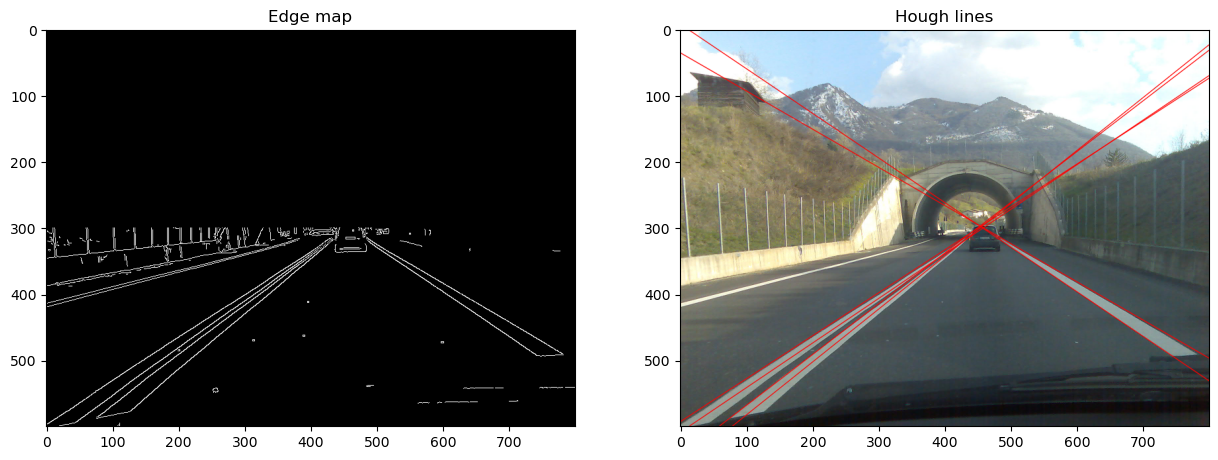

In [665]:
# Again, let's plot the resulting filtered lines
result = np.copy(img)

for line in kmeans.cluster_centers_:
    rho =  line[0]
    theta =  line[1]
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + line_len*(-b)), int(y0 + line_len*(a)))
    pt2 = (int(x0 - line_len*(-b)), int(y0 - line_len*(a)))
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

### Questions
* Do you see anything strange in the final result?
* Do you think the Hough transform resolution is important for obtaining a good result? Why?
* Do you think the Hough transform accumulator threshold is important for obtaining a good result? Why?

1. Дивним для мене стало те, що accumulator threshold впливає не тільки на кількість знайдених ліній, але й на їх якість (відношення кута і зміщення знайденої лінії в порівнянні з реальною лінією на зображенні) - лінії отримують і різні зміщення і кути. Також трохи дивним є те, що зі збільшенням роздільної здатності результат погіршується. Тобто, розмір зображення має бути оптимальним, приблизно 0.25-0.5 мпкс.
2. З рекомендованим фіксованим порогом 190 перший прийнятнний результат я отримав при зменшенні зображення до 30% від оригіналу, при менше 30% - ліній занадто мало. При збільшенні роздільної здатності кількість знайдених ліній зростає, і при розмірі 100% і вище від оригіналу кількість false-positive ліній стає дуже великою, і якість сильно погіршується.
3. Так, оскільки поріг акумулятора визначає мінімальну кількість голосів, які повинна отримати лінія, щоб бути визнаною дійсною. Якщо поріг занадто низький, можуть бути виявлені багато помилкових ліній через шум. Якщо поріг занадто високий, деякі дійсні лінії можуть бути пропущені. Тому я вирішив зробити залежність порогу від діагоналі зображення - чим більше зображення, тим вище поріг.